In [1]:
# Importing packages and setting up the formatting of figures. 

import numpy as np
import pandas as pd

# APIs
from fredapi import Fred
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

Problem 1) Tank

In [ ]:
# # Getting an overview of the available data in table IFOR41.
# IFOR41 = DstApi('IFOR41')
# IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [3]:
# Finding the appropriate variable (Gini coefficient) levels for the variable ULLIG in table IFOR41.
IFOR41.variable_levels('ULLIG',language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [4]:
# a. Downloading the gini parameter for all of denmark  
params = {
    'table': 'IFOR41',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
gini = IFOR41.get_data(params=params)


# c. display
display(gini.head(5))
display(gini.info())

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ULLIG      38 non-null     str  
 1   KOMMUNEDK  38 non-null     str  
 2   TID        38 non-null     int64
 3   INDHOLD    38 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.5 KB


None

In [5]:
def load_IFOR41(ULLIG,KOMMUNEDK,TID,varname):

    params = {
        'table': 'IFOR41',
        'format': 'BULK', # semicolon separated file
        'lang': 'en',
        'variables': [
            {'code': 'ULLIG', 'values': ['70']},
            {'code': 'KOMMUNEDK', 'values': ['000']},
            {'code': 'TID', 'values': ['*']},
            ]
    }    

    # b. download
    df = DstApi('IFOR41').get_data(params=params)

    # c. set types and rename
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df = df.drop(columns=['ULLIG'])
    df = df.rename(columns={'INDHOLD': 'Gini Coefficient', 'TID': 'year'})
    df = df.set_index('year').sort_index()
    
    return df

gini_df = load_IFOR41('70', '000', '*', 'gini')

# Vis de første 5 rækker
print(gini_df.head())

        KOMMUNEDK  Gini Coefficient
year                               
1987  All Denmark             22.07
1988  All Denmark             22.06
1989  All Denmark             21.93
1990  All Denmark             22.16
1991  All Denmark             21.99


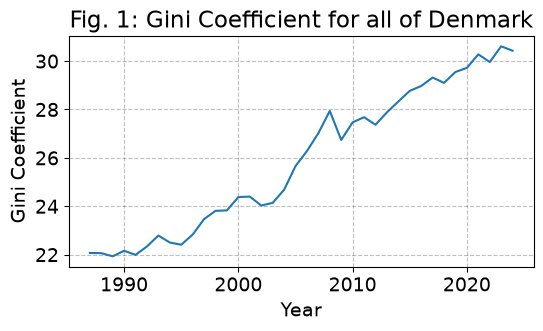

In [6]:
# Creating the plot for the Gini coefficient over time for all municipalities in Denmark.
import matplotlib.pyplot as plt
    
for col in ['Gini Coefficient']:
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(111)
    
    ax.plot(gini_df.index, gini_df[col])
    
    ax.set_title('Fig. 1: Gini Coefficient for all of Denmark')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gini Coefficient')

plt.show()

In [7]:
# Loading data from the IFOR32 table 
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [8]:
def load_IFOR32(DECILGEN, KOMMUNEDK, Tid, varname):

    params = {
        'table': 'IFOR32',
        'format': 'BULK', # semicolon separated file
        'lang': 'en',
        'variables': [
            {'code': 'DECILGEN', 'values': ['*']},
            {'code': 'KOMMUNEDK', 'values': ['000']},
            {'code': 'TID', 'values': ['*']},
            ]
    }    

    # b. download
    df = DstApi('IFOR32').get_data(params=params)

    # c. Adjusting the type to a float for the income decile variable
    df['INDHOLD'] = df['INDHOLD'].astype(float)
    df_pivot = df.pivot(index='TID', columns='DECILGEN', values='INDHOLD')

    # d. Calculating the share of income for the top 10% of the wealth distribution in Denmark
    df_pivot['top_10_share'] = df_pivot['Tenth decil'] / df_pivot.sum(axis=1)

    # e. Extracting the final column and renaming the index to 'year'
    df_final = df_pivot[['top_10_share']].copy()
    df_final.index.name = 'year'
    
    return df_final

income_10pct = load_IFOR32('*', '000', '*', 'share')

# Vis de første 5 rækker
print(income_10pct.head())

DECILGEN  top_10_share
year                  
1987          0.184549
1988          0.184289
1989          0.184952
1990          0.186415
1991          0.186683


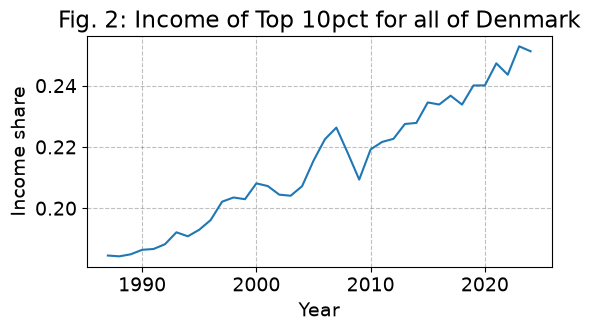

In [9]:
# Creating the plot for the Gini coefficient over time for all municipalities in Denmark.
import matplotlib.pyplot as plt
    
for col in ['top_10_share']:
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(111)
    
    ax.plot(income_10pct.index, income_10pct[col])
    
    ax.set_title('Fig. 2: Income of Top 10pct for all of Denmark')
    ax.set_xlabel('Year')
    ax.set_ylabel('Income share')

plt.show()

In [10]:
# combining the two dataframes into one and computing the correlation between the two inequality measures
import pandas as pd

# a. combining the two DataFrames on year (index)
df_merged = pd.merge(gini_df, income_10pct, left_index=True, right_index=True, validate='1:1')

# b. computing the correlation between the two inequality measures
correlation = df_merged['Gini Coefficient'].corr(df_merged['top_10_share'])

print(f"Correlation is: {correlation:.4f}")

Correlation is: 0.9816


**Comparison of the two inequality meassures for Denmark since 1987**
Figure 1 and 2 display the same overall upward trend for inequality in Denmark since 1987. 

Problem 2) 


2.1) The model is constructed in the attached .py file and imported into the notebook for simulation.



In [11]:
# ensuring that all updates to the file model is loaded into the notebook when importing:
%load_ext autoreload
%autoreload 2

# Importing the life cycle model from the p2_model.py file:
from p2_model import life_cycle_model

# running the model itself:
model = life_cycle_model()
model.sim_life_cycle_model()



Printing the simulation and analyzing the sanity checks:

In [12]:
import numpy as np

# Printing the raw simulation for the first 5 people and first 6 ages:
print("income shape:", model.income.shape)   
print(model.income[:5, :6].round(2))        

# First sanity check by making sure that the education shares matches the education probabilities:
print("education shares:", np.round(np.bincount(model.education, minlength=3)/model.N, 4))

# Second sanity check that unemployment matches the SS value at sigma/(sigma+lambda):
late = [np.mean(model.status[model.status[:,t] >= 0, t] == 0) for t in range(model.T-10, model.T)]
print("unemployment ages 55-64:", round(np.mean(late), 4),
      "  steady state:", round(model.sigma/(model.sigma+model.lam), 4))

income shape: (50000, 47)
[[0.45 0.35 1.03 1.17 1.16 1.13]
 [0.45 0.45 0.45 0.35 1.2  1.16]
 [0.45 0.45 0.45 0.35 0.82 0.77]
 [0.45 0.35 0.35 0.74 0.74 0.7 ]
 [0.45 0.35 0.35 0.83 0.8  0.84]]
education shares: [0.4026 0.3515 0.2459]
unemployment ages 55-64: 0.0911   steady state: 0.0909


Time series plot and histogram


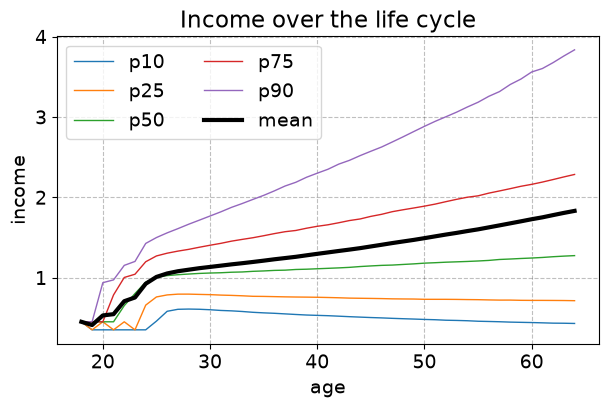

In [13]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.arange(model.age_start, model.age_retire)   # 18..64

# mean and percentiles across the simualtion:
mean_income = model.income.mean(axis=0)
pcts = [10, 25, 50, 75, 90]
P = np.percentile(model.income, pcts, axis=0)        

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
for i, p in enumerate(pcts):
    ax.plot(ages, P[i], lw=1, label=f'p{p}')
ax.plot(ages, mean_income, lw=3, color='black', label='mean')
ax.set_xlabel('age')
ax.set_ylabel('income')
ax.set_title('Income over the life cycle')
ax.legend(ncol=2)

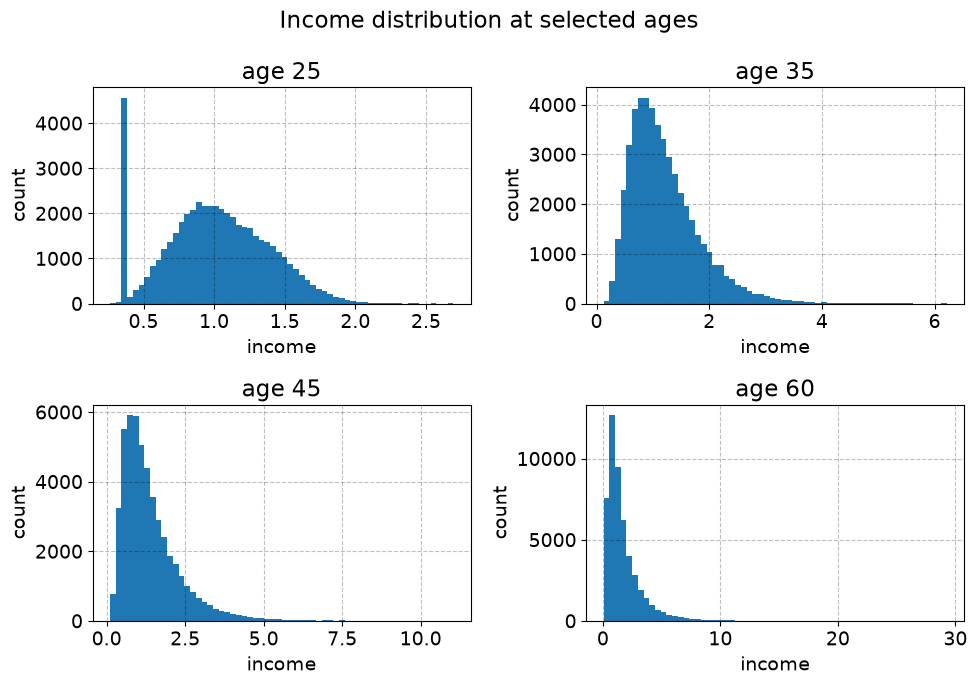

In [14]:
# histogram over the income distribution at selected ages: 
fig = plt.figure(figsize=(10, 7))
for i, age in enumerate([25, 35, 45, 60]):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.hist(model.income[:, age - model.age_start], bins=60)
    ax.set_title(f'age {age}')
    ax.set_xlabel('income')
    ax.set_ylabel('count')
fig.suptitle('Income distribution at selected ages')
fig.tight_layout()

In [15]:
# EXERCISE 1.2: Prediction 
